# 01 — Exploratory Data Analysis

Analyse exploratoire des donnees d'usage des langages de programmation.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loading import build_unified_panel, filter_twitter_programming, load_twitter_sentiment

sns.set_theme(style='whitegrid', font_scale=1.1)
FIGURES_DIR = '../reports/figures'

# Colonnes chargees et pourquoi:
# - LanguageHaveWorkedWith / LanguageWorkedWith / HaveWorkedLanguage : usage des langages (variable cible)
# - Respondent/ResponseId : comptage des repondants
# - YearsCode/YearsProgram : experience (contexte)
# - DevType : type de developpeur (contexte)
# - AISent, AIAcc (2023-2024) : sentiment IA (fallback NLP)

## Chargement du panel unifie

In [2]:
panel = build_unified_panel()
panel.to_parquet('../data/processed/language_panel.parquet', index=False)

print(f"Panel: {panel.shape[0]} lignes, {panel.language.nunique()} langages")
print(f"Sources: {panel.source.value_counts().to_dict()}")
print(f"Annees: {panel.year.min()} - {panel.year.max()}")
panel.head(10)

Panel: 1987 lignes, 206 langages
Sources: {'github': 1144, 'tiobe': 609, 'stackoverflow': 234}
Annees: 2004 - 2024


,language,year,source,usage_pct,n_respondents
0,JavaScript,2017,stackoverflow,62.457338,36625
1,SQL,2017,stackoverflow,51.205461,36625
2,Java,2017,stackoverflow,39.655973,36625
3,C#,2017,stackoverflow,34.064164,36625
4,Python,2017,stackoverflow,31.956314,36625
5,PHP,2017,stackoverflow,28.095563,36625
6,C++,2017,stackoverflow,22.266212,36625
7,C,2017,stackoverflow,19.041638,36625
8,TypeScript,2017,stackoverflow,9.523549,36625
9,Ruby,2017,stackoverflow,9.075768,36625


## Figure 1 — Trajectoire d'usage 2017-2024 (Top 20 langages, Stack Overflow)

Marqueur vertical en novembre 2022 (sortie ChatGPT).

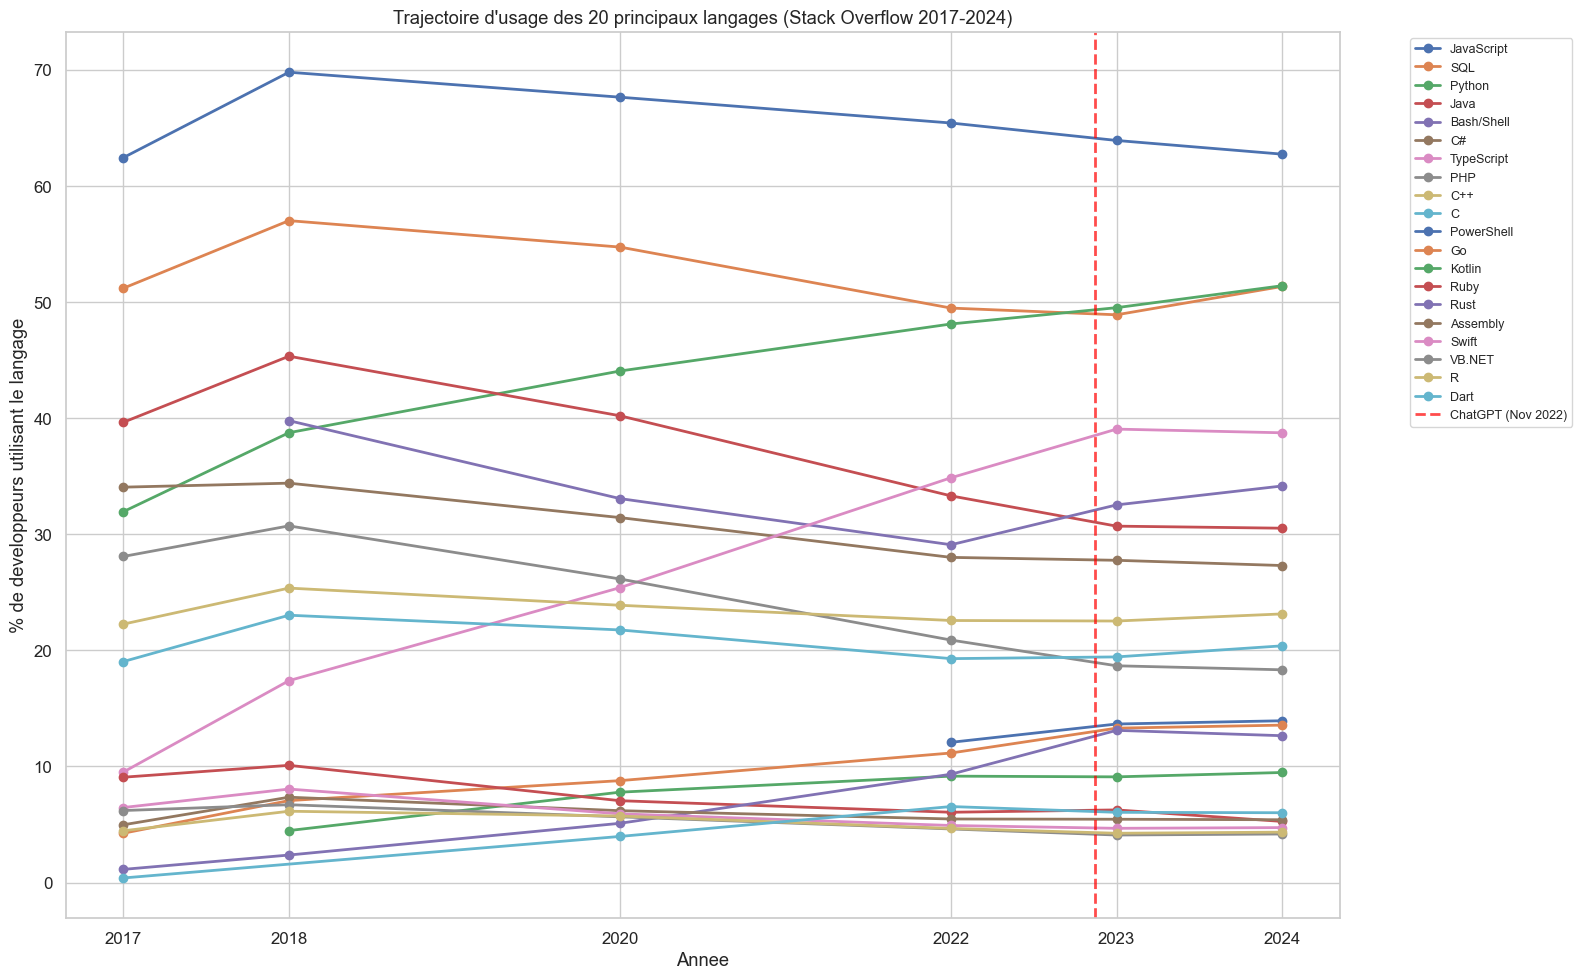

In [3]:
so = panel[panel.source == 'stackoverflow'].copy()
top20_langs = so.groupby('language')['usage_pct'].mean().nlargest(20).index.tolist()
so_top20 = so[so.language.isin(top20_langs)]

fig, ax = plt.subplots(figsize=(16, 10))
for lang in top20_langs:
    data = so_top20[so_top20.language == lang].sort_values('year')
    ax.plot(data.year, data.usage_pct, marker='o', linewidth=2, label=lang)

ax.axvline(x=2022.87, color='red', linestyle='--', linewidth=2, alpha=0.7, label='ChatGPT (Nov 2022)')
ax.set_xlabel('Annee')
ax.set_ylabel("% de developpeurs utilisant le langage")
ax.set_title("Trajectoire d'usage des 20 principaux langages (Stack Overflow 2017-2024)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticks(sorted(so.year.unique()))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_01_trajectories_top20.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Variation relative pre-LLM vs post-LLM par langage

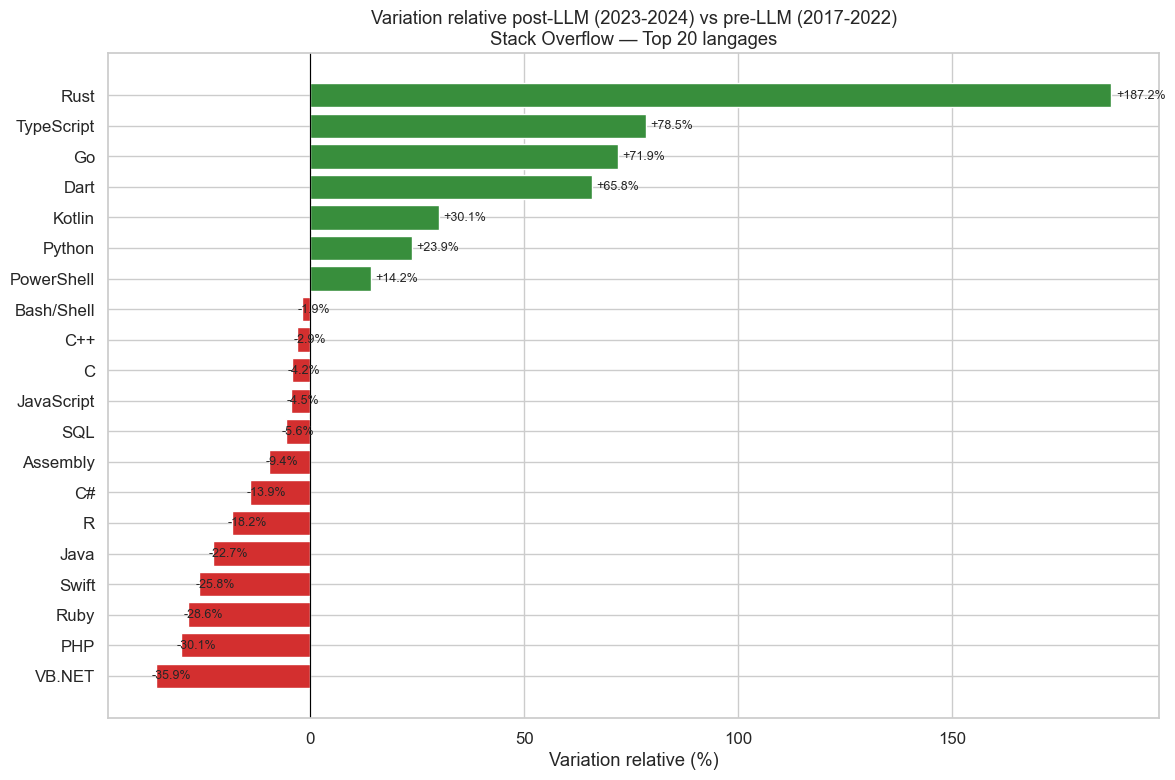

Top 5 baisses post-LLM:
language
VB.NET   -35.900782
PHP      -30.092565
Ruby     -28.593094
Swift    -25.795080
Java     -22.747316

Top 5 hausses post-LLM:
language
Kotlin         30.087708
Dart           65.777271
Go             71.909187
TypeScript     78.470607
Rust          187.153072


In [4]:
# Pre-LLM: average usage 2017-2022, Post-LLM: average usage 2023-2024
# Only SO data (most consistent series)
so_pre = so[so.year <= 2022].groupby('language')['usage_pct'].mean()
so_post = so[so.year >= 2023].groupby('language')['usage_pct'].mean()

comparison = pd.DataFrame({'pre_llm': so_pre, 'post_llm': so_post}).dropna()
comparison['change_pct'] = ((comparison.post_llm - comparison.pre_llm) / comparison.pre_llm) * 100

# Filter to top 20 languages
comp_top20 = comparison.loc[comparison.index.isin(top20_langs)].sort_values('change_pct')

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#d32f2f' if v < 0 else '#388e3c' for v in comp_top20.change_pct]
ax.barh(comp_top20.index, comp_top20.change_pct, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Variation relative (%)')
ax.set_title('Variation relative post-LLM (2023-2024) vs pre-LLM (2017-2022)\nStack Overflow — Top 20 langages')
for i, (idx, row) in enumerate(comp_top20.iterrows()):
    ax.text(row.change_pct + (1 if row.change_pct >= 0 else -1), i, f'{row.change_pct:+.1f}%', 
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_02_pre_vs_post_llm.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 baisses post-LLM:")
print(comp_top20.change_pct.head(5).to_string())
print("\nTop 5 hausses post-LLM:")
print(comp_top20.change_pct.tail(5).to_string())

## Figure 3 — Correlation Stack Overflow vs GitHub

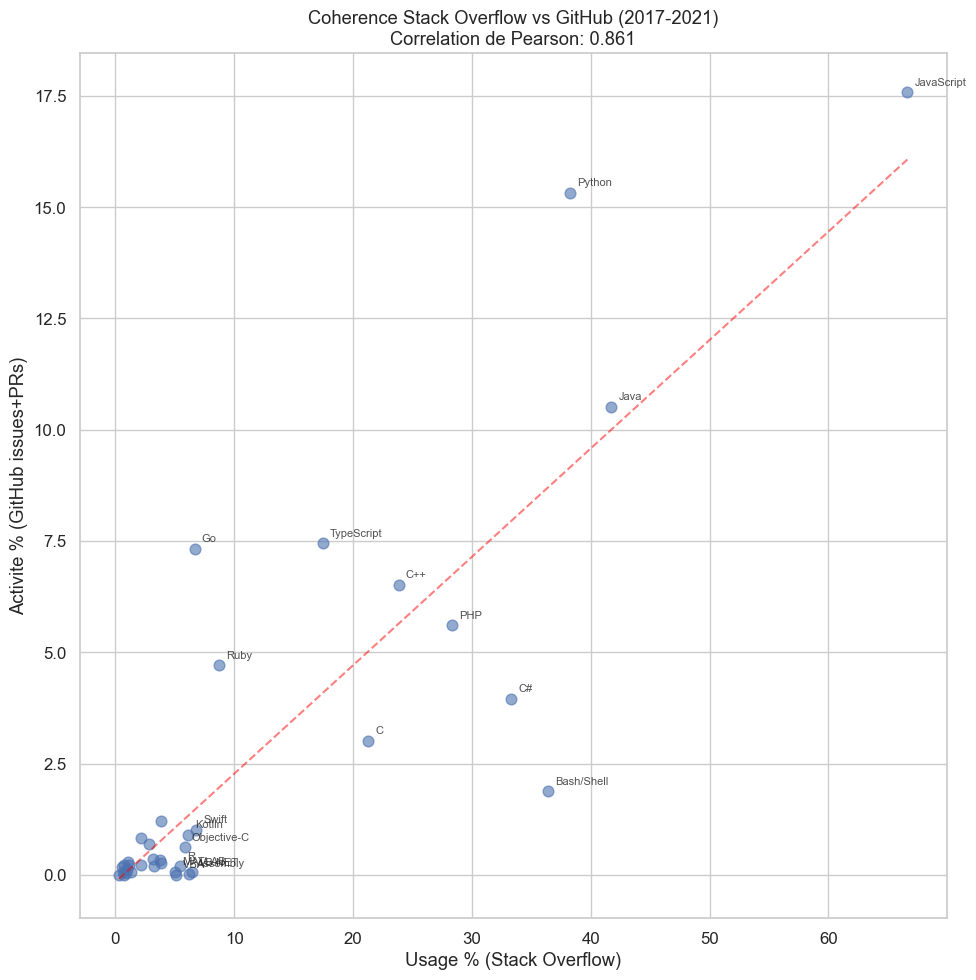

Correlation Pearson SO vs GitHub: 0.861
Langages en commun: 37


In [5]:
# Compare SO vs GitHub for overlapping years (2017-2021)
so_avg = panel[(panel.source == 'stackoverflow') & (panel.year.between(2017, 2021))].groupby('language')['usage_pct'].mean()
gh_avg = panel[(panel.source == 'github') & (panel.year.between(2017, 2021))].groupby('language')['usage_pct'].mean()

merged = pd.DataFrame({'stackoverflow': so_avg, 'github': gh_avg}).dropna()

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(merged.stackoverflow, merged.github, alpha=0.6, s=60)
for lang, row in merged.iterrows():
    if row.stackoverflow > 5 or row.github > 2:
        ax.annotate(lang, (row.stackoverflow, row.github), fontsize=8, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')

correlation = merged.stackoverflow.corr(merged.github)
ax.set_xlabel('Usage % (Stack Overflow)')
ax.set_ylabel('Activite % (GitHub issues+PRs)')
ax.set_title(f'Coherence Stack Overflow vs GitHub (2017-2021)\nCorrelation de Pearson: {correlation:.3f}')

# Trend line
z = np.polyfit(merged.stackoverflow, merged.github, 1)
p = np.poly1d(z)
x_line = np.linspace(merged.stackoverflow.min(), merged.stackoverflow.max(), 100)
ax.plot(x_line, p(x_line), '--', color='red', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_03_so_vs_github_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Correlation Pearson SO vs GitHub: {correlation:.3f}")
print(f"Langages en commun: {len(merged)}")

## Figure 4 — Top 5 plus grosses chutes et hausse depuis 2022

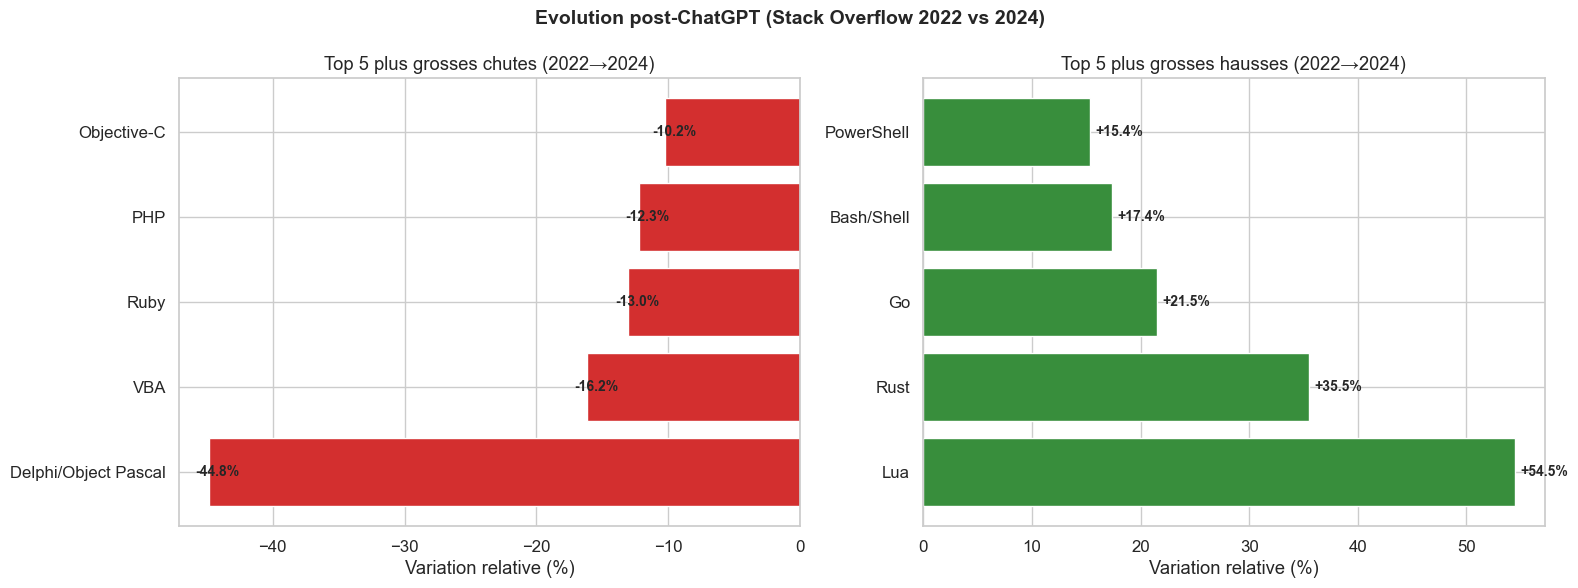

=== CHUTES ===
                           2022       2024  abs_change  rel_change
language                                                          
Delphi/Object Pascal   3.256076   1.795966   -1.460110  -44.842622
VBA                    4.487496   3.762658   -0.724838  -16.152387
Ruby                   6.057062   5.267386   -0.789676  -13.037276
PHP                   20.890454  18.329567   -2.560887  -12.258647
Objective-C            2.392392   2.147460   -0.244932  -10.237941

=== HAUSSES ===
                 2022       2024  abs_change  rel_change
language                                                
Lua          4.039451   6.239853    2.200402   54.472810
Rust         9.334273  12.652105    3.317832   35.544624
Go          11.161677  13.562641    2.400965   21.510788
Bash/Shell  29.103205  34.165202    5.061997   17.393262
PowerShell  12.081719  13.939242    1.857523   15.374657


In [6]:
# Compare 2022 vs 2024 usage in SO (post-ChatGPT window)
so_2022 = so[so.year == 2022].set_index('language')['usage_pct']
so_2024 = so[so.year == 2024].set_index('language')['usage_pct']

delta = pd.DataFrame({'2022': so_2022, '2024': so_2024}).dropna()
delta['abs_change'] = delta['2024'] - delta['2022']
delta['rel_change'] = delta['abs_change'] / delta['2022'] * 100

# Filter to languages with at least 2% usage in 2022 to avoid noise
delta_sig = delta[delta['2022'] >= 2].sort_values('rel_change')

top5_decline = delta_sig.head(5)
top5_growth = delta_sig.tail(5).sort_values('rel_change', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Declines
ax1.barh(top5_decline.index, top5_decline.rel_change, color='#d32f2f')
ax1.set_title('Top 5 plus grosses chutes (2022→2024)')
ax1.set_xlabel('Variation relative (%)')
for i, (idx, row) in enumerate(top5_decline.iterrows()):
    ax1.text(row.rel_change - 1, i, f'{row.rel_change:.1f}%', va='center', fontsize=10, fontweight='bold')

# Growth
ax2.barh(top5_growth.index, top5_growth.rel_change, color='#388e3c')
ax2.set_title('Top 5 plus grosses hausses (2022→2024)')
ax2.set_xlabel('Variation relative (%)')
for i, (idx, row) in enumerate(top5_growth.iterrows()):
    ax2.text(row.rel_change + 0.5, i, f'+{row.rel_change:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Evolution post-ChatGPT (Stack Overflow 2022 vs 2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_04_top5_decline_top5_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== CHUTES ===")
print(top5_decline[['2022', '2024', 'abs_change', 'rel_change']].to_string())
print("\n=== HAUSSES ===")
print(top5_growth[['2022', '2024', 'abs_change', 'rel_change']].to_string())

## Figure 5 — Heatmap de volatilite par langage

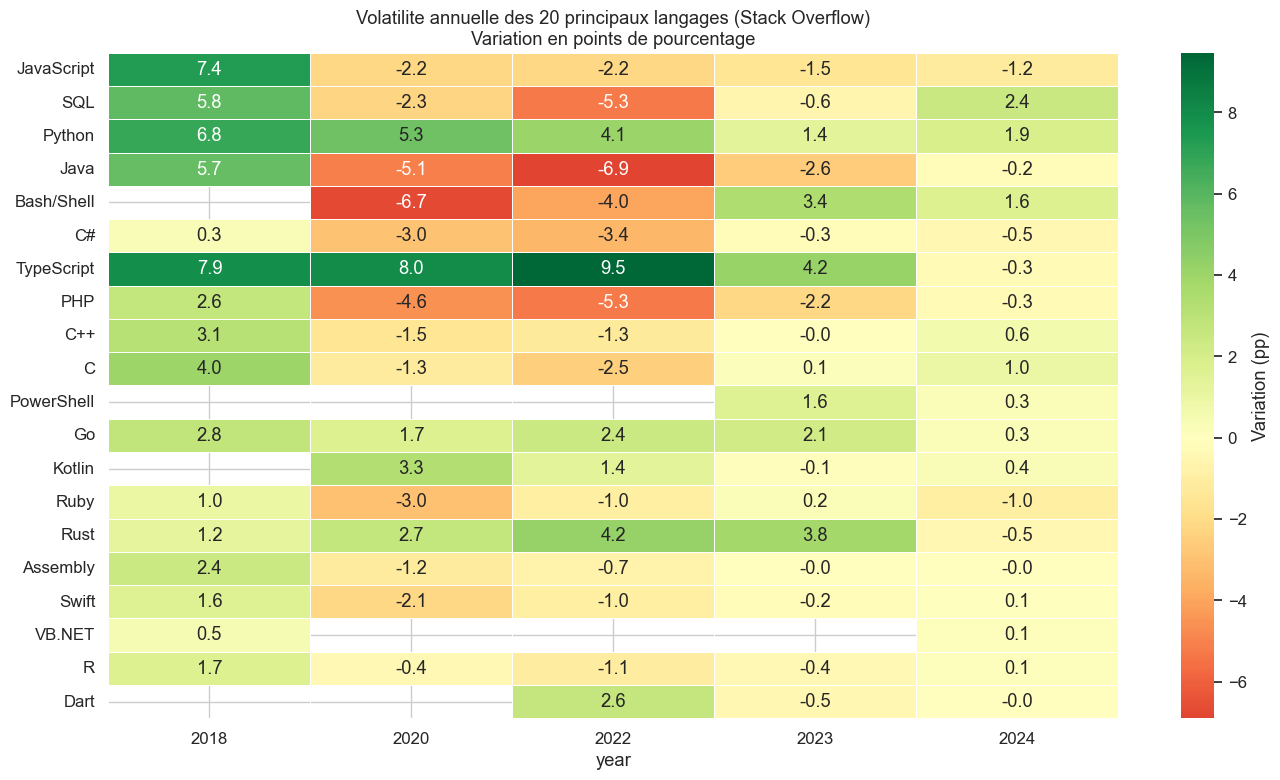

In [7]:
# Volatility = variation d'usage d'une annee a l'autre (SO)
so_pivot = so[so.language.isin(top20_langs)].pivot_table(
    index='language', columns='year', values='usage_pct'
)
# Calculate year-over-year change
so_changes = so_pivot.diff(axis=1).iloc[:, 1:]  # Drop first NaN column

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(so_changes.loc[top20_langs], annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Variation (pp)'})
ax.set_title('Volatilite annuelle des 20 principaux langages (Stack Overflow)\nVariation en points de pourcentage')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_05_volatility_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 6 — Evolution des parts de marche (stacked area, top 10)

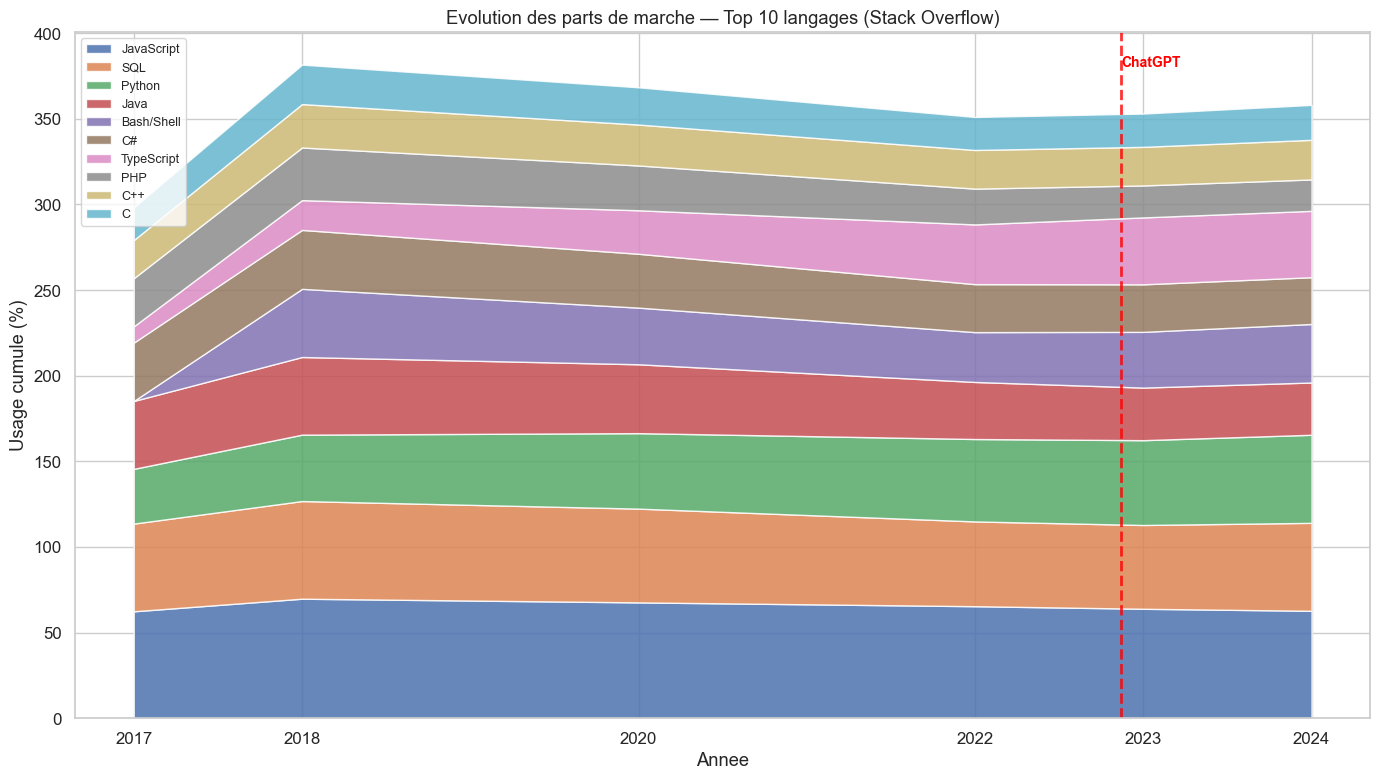

In [8]:
# Stacked area: top 10 langages SO, normalisees a 100%
top10_langs = so.groupby('language')['usage_pct'].mean().nlargest(10).index.tolist()
so_top10 = so[so.language.isin(top10_langs)].pivot_table(
    index='year', columns='language', values='usage_pct'
).fillna(0)
# Reorder columns by average usage
so_top10 = so_top10[top10_langs]

fig, ax = plt.subplots(figsize=(14, 8))
ax.stackplot(so_top10.index, so_top10.T.values, labels=so_top10.columns, alpha=0.85)
ax.axvline(x=2022.87, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax.annotate('ChatGPT', xy=(2022.87, ax.get_ylim()[1] * 0.95), fontsize=10, color='red', fontweight='bold')
ax.set_xlabel('Annee')
ax.set_ylabel('Usage cumule (%)')
ax.set_title('Evolution des parts de marche — Top 10 langages (Stack Overflow)')
ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(sorted(so.year.unique()))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_06_share_evolution_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

## Verification Twitter sentiment (filtrage langages + IA)

In [9]:
# Check Twitter sentiment dataset: how many tweets survive the programming filter?
train, val = load_twitter_sentiment()
print(f"Twitter training: {len(train)} tweets")
print(f"Twitter validation: {len(val)} tweets")

train_filtered = filter_twitter_programming(train)
val_filtered = filter_twitter_programming(val)
total_filtered = len(train_filtered) + len(val_filtered)

print(f"\nApres filtrage langages+IA:")
print(f"  Training: {len(train_filtered)} tweets")
print(f"  Validation: {len(val_filtered)} tweets")
print(f"  Total: {total_filtered} tweets")

if total_filtered < 500:
    print(f"\n⚠ SEULEMENT {total_filtered} tweets exploitables (< 500)")
    print("→ Fallback recommande: utiliser les colonnes AISent/AIAcc des SO 2023/2024")
else:
    print(f"\n✓ {total_filtered} tweets exploitables (>= 500)")

# Show sentiment distribution in filtered data
print(f"\nDistribution des sentiments (tweets filtres):")
print(train_filtered['sentiment'].value_counts().to_string())

Twitter training: 74682 tweets
Twitter validation: 1000 tweets

Apres filtrage langages+IA:
  Training: 25808 tweets
  Validation: 402 tweets
  Total: 26210 tweets

✓ 26210 tweets exploitables (>= 500)

Distribution des sentiments (tweets filtres):
sentiment
Negative      7682
Positive      7018
Neutral       6323
Irrelevant    4785
